In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("iris.csv")

X = data.drop("species", axis=1)
y = data["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Linear Kernel
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)
pred_linear = linear_model.predict(X_test)

# RBF Kernel
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)
pred_rbf = rbf_model.predict(X_test)

# Results
print("Linear Accuracy:", accuracy_score(y_test, pred_linear))
print("Linear Confusion Matrix:\n", confusion_matrix(y_test, pred_linear))

print("\nRBF Accuracy:", accuracy_score(y_test, pred_rbf))
print("RBF Confusion Matrix:\n", confusion_matrix(y_test, pred_rbf))

Linear Accuracy: 1.0
Linear Confusion Matrix:
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]

RBF Accuracy: 1.0
RBF Confusion Matrix:
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


Accuracy: 0.9335


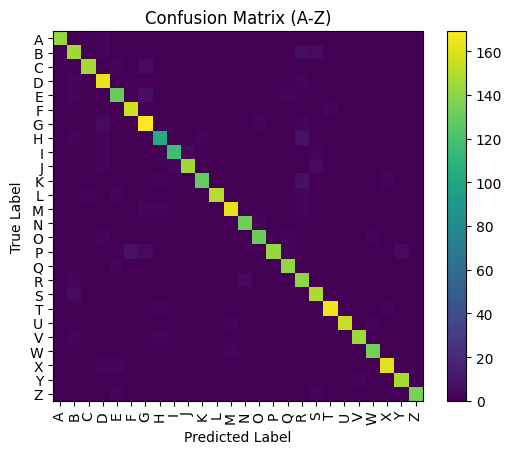

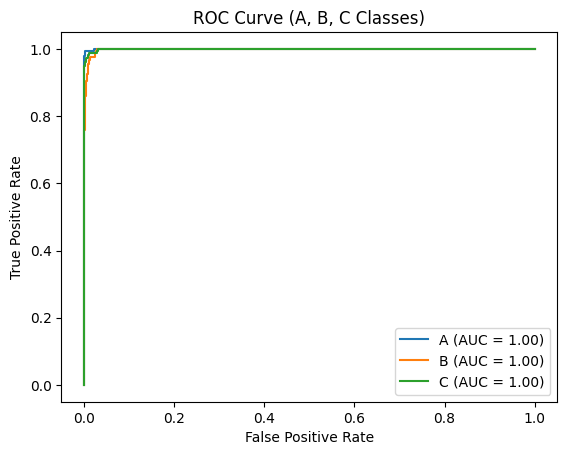

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# Load dataset
data = pd.read_csv("letter-recognition.csv")

# Split features & target
X = data.drop("letter", axis=1)
y = data["letter"]

# Encode labels (A-Z → 0-25)
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Train SVM model (RBF kernel)
model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# =========================
# ✅ Confusion Matrix (A–Z labels)
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (A-Z)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Label axes with A-Z
classes = list(le.classes_)
plt.xticks(np.arange(26), classes, rotation=90)
plt.yticks(np.arange(26), classes)

plt.show()

# =========================
# ✅ ROC Curve (3 classes for clarity)
# =========================
y_test_bin = label_binarize(y_test, classes=range(26))

plt.figure()

for i in range(3):  # First 3 classes (A, B, C)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (A, B, C Classes)")
plt.legend()

plt.show()